In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

#sklearn classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


#Pipeline
from sklearn.pipeline import Pipeline

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

#Dimensionality Reduction
from sklearn.decomposition import PCA

#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#Evaluation Metrics F1, ROC OVR
# Balanced Accuracy,

# · The macro-average and micro-average of the One-vs-Rest ROC AUC score.

# In addition,

# · Draw the macro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.

# · Draw the micro-average One-vs-Rest ROCs for all classification methods into a single graph to allow for easy comparison between methods.

# · For each class, draw the One-vs-Rest ROCs for all classification methods into a separate graph, to allow for easy comparison between methods.
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

#Confusion Matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay





In [2]:
#data load
from sklearn.datasets import fetch_openml

dataset = fetch_openml(data_id=4538, as_frame=False) # fetch the dataset


In [3]:

X = dataset.data
y = dataset.target


print(X.shape)
print(y.shape)

#checking integrity of data
distribution = np.unique(y, return_counts=True)
isnan = np.isnan(X).sum()

print("general distribution of data :", distribution)
print("Nans in data :", isnan)


(9873, 32)
(9873,)
general distribution of data : (array(['D', 'H', 'P', 'R', 'S'], dtype=object), array([2741,  998, 2097, 1087, 2950]))
Nans in data : 0


In [4]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

outlier_labels = iso.fit_predict(X)
# -1 = outlier, 1 = inlier

n_outliers = (outlier_labels == -1).sum()
print("Detected outliers:", n_outliers)

Detected outliers: 494


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, stratify=y, random_state=42)
#for KNN might delete later
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)


In [15]:
#Model Selection without hyperparameter tuning

models = [
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    LinearSVC(),
    SVC(),
    GaussianNB()
]

model_names = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "KNN",
    "Linear SVC",
    "SVC",
    "Naive Bayes"
]

results = {}
for name, model in zip(model_names, models):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = balanced_accuracy_score(y_test, y_pred)
    results[name] = acc

print(results)

{'Logistic Regression': 0.30748896861726255, 'Decision Tree': 0.468910998587328, 'Random Forest': 0.5870761006573666, 'KNN': 0.5581649197515796, 'Linear SVC': 0.3062805205741361, 'SVC': 0.4300664411211203, 'Naive Bayes': 0.3425543766949714}


## All hypertuned models

In [ ]:
#hyperparameter tuning with and finding out the best hyper parameter
models = {
     "Logistic Regression": (
        Pipeline([
            ("scaler", RobustScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "clf__C": [0.001, 0.01, 0.1, 1, 10,100]
        }
    ),
    
    "Logistic Regression (PCA)": (
        Pipeline([
            ("scaler", RobustScaler()),
            ("pca", PCA()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "pca__n_components": [5, 10, 15, 20, 25],
            "clf__C": [0.001, 0.01, 0.1, 1, 10,100]
        }
    ),

    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),
        {
            "max_depth": [None, 10, 20, 30],
            "min_samples_leaf": [1, 5, 10]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),
        {
            "n_estimators": [200, 500],
            "max_depth": [None, 15, 30],
            "min_samples_leaf": [1, 5]
        }
    ),   

    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                algorithm="brute",
            ))
        ]),
        {
            "clf__n_neighbors": list(range(1, 51, 2)),
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan"]
        }
    ),

    "Linear SVC": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                class_weight="balanced",
                max_iter=5000
            ))
        ]),
        {
            "clf__C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100], 
            "clf__loss": ["squared_hinge"],
            "clf__dual": [False] 
        }
    ),
    
    "SVC (RBF)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False
            ))
        ]),
        {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": [0.001, 0.01, 0.1]
        }
    ),

    "Naive Bayes": (
        GaussianNB(),
        {
            "var_smoothing": np.logspace(-12, -6, 20)
        }
    ),
    
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [200],
            "learning_rate": [0.1],
            "max_depth": [5],
            "subsample": [0.8]
        }
    )
}


tuned_results = {}
best_models = {}
acc=0.0;
for name, (model, params) in models.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1
    )
    if name=="KNN":
        grid.fit(X_train, y_train_enc)    
    
        best_model = grid.best_estimator_
        y_pred_enc = best_model.predict(X_test)
        y_pred = le.inverse_transform(y_pred_enc)

        acc = balanced_accuracy_score(y_test, y_pred)
    else:
        grid.fit(X_train, y_train)
    
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
    
        acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results[name] = acc
    best_models[name] = best_model

print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results.items():
    print(f"{k}: {v:.4f}")

print("\nBest Hyperparameters:")
for k, v in best_models.items():
    print(f"{k}: {v}")



Tuning Logistic Regression ...

Tuning Logistic Regression (PCA) ...

Tuning Decision Tree ...

Tuning Random Forest ...

Tuning KNN ...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[Errno 2] No such file or directory: 'sysctl'
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/backend/context.py", line 249, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_darwin()
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/backend/context.py", line 312, in _count_physical_cores_darwin
    cpu_info = subprocess.run(
        "sysctl -n hw.physicalcpu".split(),
        capture_output=True,
        text=True,
    )
  File "/Library/Frameworks/Python.framework/Versions/3.13


Tuning Linear SVC ...

Tuning SVC (RBF) ...

Tuning Naive Bayes ...

Tuning Gradient Boosting ...

Tuned Results (Balanced Accuracy):
Logistic Regression: 0.4363
Logistic Regression (PCA): 0.4191
Decision Tree: 0.4729
Random Forest: 0.6052
KNN: 0.6354
Linear SVC: 0.4085
SVC (RBF): 0.5166
Naive Bayes: 0.3426
Gradient Boosting: 0.5951

Best Hyperparameters:
Logistic Regression: {'clf__C': 0.1}
Logistic Regression (PCA): {'clf__C': 1, 'pca__n_components': 25}
Decision Tree: {'max_depth': 10, 'min_samples_leaf': 5}
Random Forest: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 500}
KNN: {'clf__metric': 'manhattan', 'clf__n_neighbors': 1, 'clf__weights': 'uniform'}
Linear SVC: {'clf__C': 10, 'clf__dual': False, 'clf__loss': 'squared_hinge'}
SVC (RBF): {'clf__C': 10, 'clf__gamma': 0.1}
Naive Bayes: {'var_smoothing': np.float64(1e-12)}
Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


## Logistic Regression

In [18]:
models_lr = {
    "Logistic Regression": (
        Pipeline([
            ("scaler", RobustScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "clf__C": [0.001, 0.01, 0.1, 1, 10,100]
        }
    ),
    "Logistic Regression (PCA)": (
        Pipeline([
            ("scaler", RobustScaler()),
            ("pca", PCA()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "pca__n_components": [5 ,10, 15, 20],
            "clf__C": [0.001, 0.01, 0.1, 1, 10,100]
        }
    ),

}

tuned_results_lr = {}
best_models_lr = {}
best_params_lr = {}

for name, (model, params) in models_lr.items():    
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results_lr[name] = acc
    best_models_lr[name] = best_model
    best_params_lr[name] = grid.best_params_
    
print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_lr.items():
    print(f"{k}: {v:.4f}")

print("\nBest Model:")
for k, v in best_models_lr.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameter:")
for k, v in best_params_lr.items():
    print(f"{k}: {v}")



Tuning Logistic Regression ...

Tuning Logistic Regression (PCA) ...

Tuned Results (Balanced Accuracy):
Logistic Regression: 0.4363
Logistic Regression (PCA): 0.4009

Best Model:
Logistic Regression: Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=2000, random_state=42))])
Logistic Regression (PCA): Pipeline(steps=[('scaler', RobustScaler()), ('pca', PCA(n_components=20)),
                ('clf',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=2000, random_state=42))])

Best Hyperparameter:
Logistic Regression: {'clf__C': 0.1}
Logistic Regression (PCA): {'clf__C': 0.001, 'pca__n_components': 20}


## Decision Tree

In [ ]:
models_dt = {
    "Decision Tree": (
        Pipeline([
            ("dt", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "dt__max_depth": [None ,5 , 10, 20],
            "dt__min_samples_leaf": [1, 5, 10]
        }
        
    ),
    "Decision Tree (PCA)": (
        Pipeline([
            ("pca", PCA()),
            ("dt", DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "dt__max_depth": [None ,5 , 10, 20],
            "dt__min_samples_leaf": [1, 5, 10]
        }
        
    ),
    
}

tuned_results_dt = {}
best_models_dt = {}
best_params_dt = {}

for name, (model, params) in models_dt.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results_dt[name] = acc
    best_models_dt[name] = best_model
    best_params_dt[name] = grid.best_params_
    
print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_dt.items():
    print(f"{k}: {v:.4f}")

print("\nBest Model:")
for k, v in best_models_dt.items():
    print(f"{k}: {v}")

print("\nBest Parameter:")
for k, v in best_params_dt.items():
    print(f"{k}: {v}")


#0.4814 PCA 095


Tuning Decision Tree ...

Tuning Decision Tree (PCA) ...

Tuned Results (Balanced Accuracy):
Decision Tree: 0.4729
Decision Tree (PCA): 0.4814

Best Model:
Decision Tree: Pipeline(steps=[('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5, random_state=42))])
Decision Tree (PCA): Pipeline(steps=[('pca', PCA(n_components=10)),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                                        random_state=42))])

Best Parameter:
Decision Tree: {'dt__max_depth': 10, 'dt__min_samples_leaf': 5}
Decision Tree (PCA): {'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'pca__n_components': 10}


## Random Forest

In [20]:
models_rf = {
    "Random Forest": (
        Pipeline([
            ("rf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "rf__n_estimators": [500],
            "rf__max_depth": [None],
            "rf__min_samples_leaf": [5]
        }
        
    ),
    "Random Forest (PCA)": (
        Pipeline([
            ("pca", PCA()),
            ("rf", RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ))
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "rf__n_estimators": [200],
            "rf__max_depth": [None],
            "rf__min_samples_leaf": [5]
        }
    ),
}

tuned_results_rf = {}
best_models_rf = {}
best_params_rf ={}

for name, (model, params) in models_rf.items():    
    
    print(f"\nTuning {name} ...")
    
    
    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results_rf[name] = acc
    best_models_rf[name] = best_model
    best_params_rf[name] = grid.best_params_

print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_rf.items():
    print(f"{k}: {v:.4f}")

print("\nBest Models:")
for k, v in best_models_rf.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameters:")
for k, v in best_params_rf.items():
    print(f"{k}: {v}")



Tuning Random Forest ...

Tuning Random Forest (PCA) ...

Tuned Results (Balanced Accuracy):
Random Forest: 0.6052
Random Forest (PCA): 0.5820

Best Models:
Random Forest: Pipeline(steps=[('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=500,
                                        random_state=42))])
Random Forest (PCA): Pipeline(steps=[('pca', PCA(n_components=20)),
                ('rf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=200,
                                        random_state=42))])

Best Hyperparameters:
Random Forest: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 500}
Random Forest (PCA): {'pca__n_components': 20, 'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}


In [22]:


models_knn = {
    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                algorithm="brute",
            ))
        ]),
        {
            "clf__n_neighbors": list(range(1, 51, 2)),
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan"]
        }
    ),
    "KNN (PCA)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("clf", KNeighborsClassifier(
                algorithm="brute",
            ))
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "clf__n_neighbors": list(range(1, 51, 2)),
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan"]
        }
    ),
    
}


tuned_results_knn = {}
best_models_knn = {}
best_params_knn = {}


for name, (model, params) in models_knn.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1,
        error_score="raise"
    )
    
    grid.fit(X_train, y_train_enc)    
    
    best_model = grid.best_estimator_
    y_pred_enc = best_model.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)

    acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results_knn[name] = acc
    best_models_knn[name] = best_model
    best_params_knn[name] = grid.best_params_

print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_knn.items():
    print(f"{k}: {v:.4f}")

print("\nBest Models:")
for k, v in best_models_knn.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameters:")
for k, v in best_params_knn.items():
    print(f"{k}: {v}")





Tuning KNN ...

Tuning KNN (PCA) ...

Tuned Results (Balanced Accuracy):
KNN: 0.6354
KNN (PCA): 0.5668

Best Models:
KNN: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 KNeighborsClassifier(algorithm='brute', metric='manhattan',
                                      n_neighbors=1))])
KNN (PCA): Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=20)),
                ('clf',
                 KNeighborsClassifier(algorithm='brute', metric='euclidean',
                                      n_neighbors=1))])

Best Hyperparameters:
KNN: {'clf__metric': 'manhattan', 'clf__n_neighbors': 1, 'clf__weights': 'uniform'}
KNN (PCA): {'clf__metric': 'euclidean', 'clf__n_neighbors': 1, 'clf__weights': 'uniform', 'pca__n_components': 20}


In [23]:
models_svc = {
    "Linear SVC": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                class_weight="balanced",
                max_iter=5000
            ))
        ]),
        {
            "clf__C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100], 
            "clf__loss": ["squared_hinge"],
            "clf__dual": [False] 
        }
    ),
    "Linear SVC (PCA)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("clf", LinearSVC(
                class_weight="balanced",
                max_iter=5000
            ))
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "clf__C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100], 
            "clf__loss": ["squared_hinge"],
            "clf__dual": [False] 
        }
    ),
    "SVC (RBF)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False
            ))
        ]),
        {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": [0.001, 0.01, 0.1]
        }
    ),
    "SVC [RBF] (PCA)": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA()),
            ("clf", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False
            ))
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": [0.001, 0.01, 0.1]
        }
    ),
}

tuned_results_svc = {}
best_models_svc = {}
best_params_svc = {}

for name, (model, param_grid) in models_svc.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=3,             
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = balanced_accuracy_score(y_test, y_pred)

    tuned_results_svc[name] = acc
    best_models_svc[name] = best_model
    best_params_svc[name] = grid.best_params_

print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_svc.items():
    print(f"{k}: {v:.4f}")

print("\nBest Hyperparameters:")
for k, v in best_models_svc.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameters:")
for k, v in best_params_svc.items():
    print(f"{k}: {v}")




Tuning Linear SVC ...
Fitting 3 folds for each of 7 candidates, totalling 21 fits

Tuning Linear SVC (PCA) ...
Fitting 3 folds for each of 28 candidates, totalling 84 fits

Tuning SVC (RBF) ...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Tuning SVC [RBF] (PCA) ...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Tuned Results (Balanced Accuracy):
Linear SVC: 0.4085
Linear SVC (PCA): 0.3921
SVC (RBF): 0.5166
SVC [RBF] (PCA): 0.4985

Best Hyperparameters:
Linear SVC: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LinearSVC(C=10, class_weight='balanced', dual=False,
                           max_iter=5000))])
Linear SVC (PCA): Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=20)),
                ('clf',
                 LinearSVC(C=1, class_weight='balanced', dual=False,
                           max_iter=5000))])
SVC (RBF): Pipeline(steps=[('scaler', StandardScaler()),
                ('clf'

In [25]:

models_nb = {
    "Naive Bayes": (
        Pipeline([
            ("nb", GaussianNB())
        ]),
        {
            "nb__var_smoothing": np.logspace(-12, -6, 20)
        }
    ),
    "Naive Bayes (PCA)": (
        Pipeline([
            ("pca", PCA()),
            ("nb", GaussianNB())
        ]),
        {
            "pca__n_components": [5 ,10 ,15 ,20],
            "nb__var_smoothing": np.logspace(-12, -6, 20)

        }
    ),
}

tuned_results_nb = {}
best_models_nb = {}
best_params_nb = {}

for name, (model, params) in models_nb.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        model,
        params,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    acc = balanced_accuracy_score(y_test, y_pred)
    
    tuned_results_nb[name] = acc
    best_models_nb[name] = best_model
    best_params_nb[name] = grid.best_params_

print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_nb.items():
    print(f"{k}: {v:.4f}")

print("\nBest Models:")
for k, v in best_models_nb.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameters:")
for k, v in best_params_nb.items():
    print(f"{k}: {v}")


Tuning Naive Bayes ...

Tuning Naive Bayes (PCA) ...

Tuned Results (Balanced Accuracy):
Naive Bayes: 0.3426
Naive Bayes (PCA): 0.3219

Best Models:
Naive Bayes: Pipeline(steps=[('nb', GaussianNB(var_smoothing=np.float64(1e-12)))])
Naive Bayes (PCA): Pipeline(steps=[('pca', PCA(n_components=15)),
                ('nb', GaussianNB(var_smoothing=np.float64(1e-12)))])

Best Hyperparameters:
Naive Bayes: {'nb__var_smoothing': np.float64(1e-12)}
Naive Bayes (PCA): {'nb__var_smoothing': np.float64(1e-12), 'pca__n_components': 15}


In [6]:
models_gb = {
    "Gradient Boosting": (
        Pipeline([
            ("gb", GradientBoostingClassifier(random_state=42))
        ]),
        {
            "gb__n_estimators": [200],
            "gb__learning_rate": [0.1],
            "gb__max_depth": [5],
            "gb__subsample": [0.8]
        }
    ),
     "Gradient Boosting (PCA)": (
        Pipeline([
            ("pca", PCA()),
            ("gb", GradientBoostingClassifier(random_state=42))
        ]),
        {
            "pca__n_components": [20],
            "gb__n_estimators": [200],
            "gb__learning_rate": [0.1],
            "gb__max_depth": [5],
            "gb__subsample": [0.8]
        }
    ),
}

tuned_results_gb = {}
best_models_gb = {}
best_params_gb = {}

for name, (model, param_grid) in models_gb.items():
    print(f"\nTuning {name} ...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = balanced_accuracy_score(y_test, y_pred)

    tuned_results_gb[name] = acc
    best_models_gb[name] = best_model
    best_params_gb[name] = grid.best_params_


print("\nTuned Results (Balanced Accuracy):")
for k, v in tuned_results_gb.items():
    print(f"{k}: {v:.4f}")

print("\nBest Models:")
for k, v in best_models_gb.items():
    print(f"{k}: {v}")

print("\nBest Hyperparameters:")
for k, v in best_params_gb.items():
    print(f"{k}: {v}")


Tuning Gradient Boosting ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Tuning Gradient Boosting (PCA) ...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Tuned Results (Balanced Accuracy):
Gradient Boosting: 0.5951
Gradient Boosting (PCA): 0.5517

Best Models:
Gradient Boosting: Pipeline(steps=[('gb',
                 GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                            random_state=42, subsample=0.8))])
Gradient Boosting (PCA): Pipeline(steps=[('pca', PCA(n_components=20)),
                ('gb',
                 GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                            random_state=42, subsample=0.8))])

Best Hyperparameters:
Gradient Boosting: {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200, 'gb__subsample': 0.8}
Gradient Boosting (PCA): {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200, 'gb__subsample': 0.8, 'pca__n_

### Logistic Regression

Tuned Results (Balanced Accuracy):
Logistic Regression: 0.4363
Logistic Regression (PCA): 0.4009

Best Hyperparameter:
Logistic Regression: {'clf__C': 0.1}
Logistic Regression (PCA): {'clf__C': 0.001, 'pca__n_components': 20}

### Decision Tree

Tuned Results (Balanced Accuracy):
Decision Tree: 0.4729
Decision Tree with Hyperparameters: 0.4729

Best Parameter:
Decision Tree: {'dt__max_depth': 10, 'dt__min_samples_leaf': 5}
Decision Tree (PCA): {'dt__max_depth': 10, 'dt__min_samples_leaf': 1, 'pca__n_components': 10}



### Random Forest

Tuned Results (Balanced Accuracy):
Random Forest: 0.6052
Random Forest (PCA): 0.5820

Best Hyperparameters:
Random Forest: {'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 500}
Random Forest (PCA): {'pca__n_components': 20, 'rf__max_depth': None, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 200}

### KNN 

Tuned Results (Balanced Accuracy):
KNN: 0.6354
KNN (PCA): 0.5668

Best Hyperparameters:
KNN: {'clf__metric': 'manhattan', 'clf__n_neighbors': 1, 'clf__weights': 'uniform'}
KNN (PCA): {'clf__metric': 'euclidean', 'clf__n_neighbors': 1, 'clf__weights': 'uniform', 'pca__n_components': 20}

### Linear SVC

Tuned Results (Balanced Accuracy):
Linear SVC: 0.4085
Linear SVC (PCA): 0.3921

Best Hyperparameters:
Linear SVC: {'clf__C': 10, 'clf__dual': False, 'clf__loss': 'squared_hinge'}
Linear SVC (PCA): {'clf__C': 1, 'clf__dual': False, 'clf__loss': 'squared_hinge', 'pca__n_components': 20}
SVC (RBF): {'clf__C': 10, 'clf__gamma': 0.1}
SVC [RBF] (PCA): {'clf__C': 10, 'clf__gamma': 0.1, 'pca__n_components': 15}

### SVC RBF

Tuned Results (Balanced Accuracy):
SVC (RBF): 0.5166
SVC [RBF] (PCA): 0.4985

Best Hyperparameters:
SVC (RBF): {'clf__C': 10, 'clf__gamma': 0.1}
SVC [RBF] (PCA): {'clf__C': 10, 'clf__gamma': 0.1, 'pca__n_components': 15}

### Naive Bayes

Tuned Results (Balanced Accuracy):
Naive Bayes: 0.3426
Naive Bayes (PCA): 0.3219

Best Hyperparameters:
Naive Bayes: {'nb__var_smoothing': np.float64(1e-12)}
Naive Bayes (PCA): {'nb__var_smoothing': np.float64(1e-12), 'pca__n_components': 15}


### Gradient Boosting

Tuned Results (Balanced Accuracy):
Gradient Boosting: 0.5951
Gradient Boosting (PCA): 0.5517

Best Hyperparameters:
Gradient Boosting: {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200, 'gb__subsample': 0.8}
Gradient Boosting (PCA): {'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200, 'gb__subsample': 0.8, 'pca__n_components': 20}

In [7]:
def evaluate_multiclass_model(
    model,
    X_test,
    y_test,
    class_labels,
    model_name
):
  

    y_pred = model.predict(X_test)

    # ----- Balanced Accuracy -----
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # ----- Scores for ROC -----
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    else:
        scores = model.predict_proba(X_test)

    # Binarize labels
    y_bin = label_binarize(y_test, classes=class_labels)

    # ----- ROC-AUC -----
    macro_auc = roc_auc_score(
        y_bin, scores, multi_class="ovr", average="macro"
    )
    micro_auc = roc_auc_score(
        y_bin, scores, multi_class="ovr", average="micro"
    )

    # ----- ROC Curves -----
    fpr = {}
    tpr = {}

    for i, cls in enumerate(class_labels):
        fpr[cls], tpr[cls], _ = roc_curve(y_bin[:, i], scores[:, i])

    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_bin.ravel(), scores.ravel()
    )

    # ----- Confusion Matrix -----
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix – {model_name}")
    plt.show()

    return {
        "model": model_name,
        "balanced_accuracy": bal_acc,
        "macro_auc": macro_auc,
        "micro_auc": micro_auc,
        "fpr": fpr,
        "tpr": tpr
    }


In [9]:
results = []

for name, model in best_models_lr.items():
    res = evaluate_multiclass_model(
        model,
        X_test,
        y_test,
        class_labels=np.unique(y_test),
        model_name=name
    )
    results.append(res)


NameError: name 'best_models_lr' is not defined

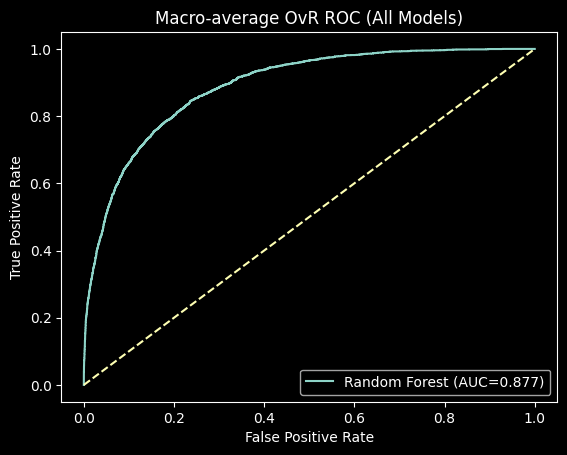

In [15]:
plt.figure()
for r in results:
    plt.plot(
        r["fpr"]["micro"],
        r["tpr"]["micro"],
        label=f"{r['model']} (AUC={r['macro_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-average OvR ROC (All Models)")
plt.legend()
plt.show()


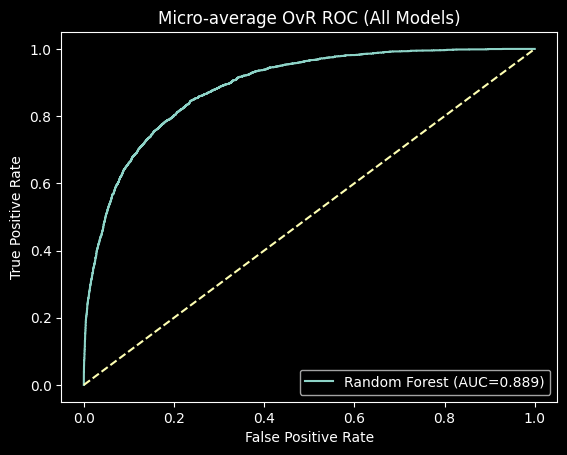

In [16]:
plt.figure()
for r in results:
    plt.plot(
        r["fpr"]["micro"],
        r["tpr"]["micro"],
        label=f"{r['model']} (AUC={r['micro_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average OvR ROC (All Models)")
plt.legend()
plt.show()


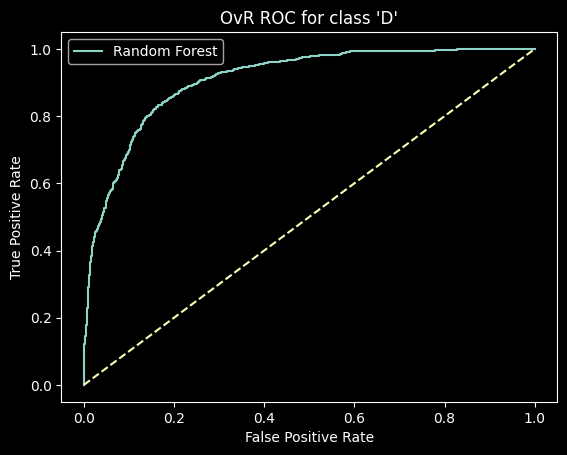

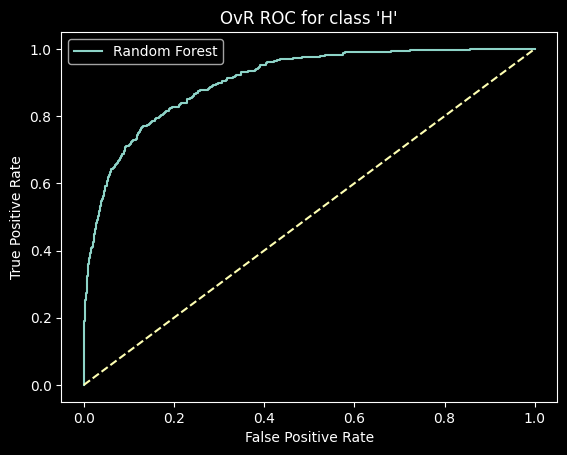

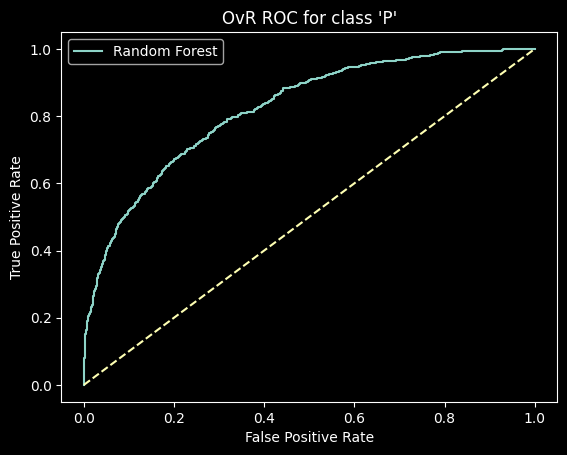

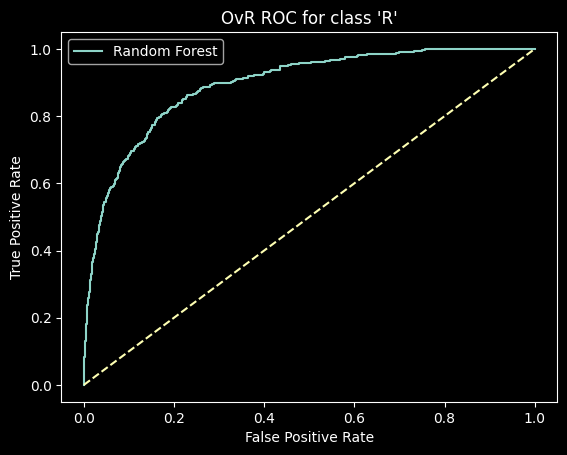

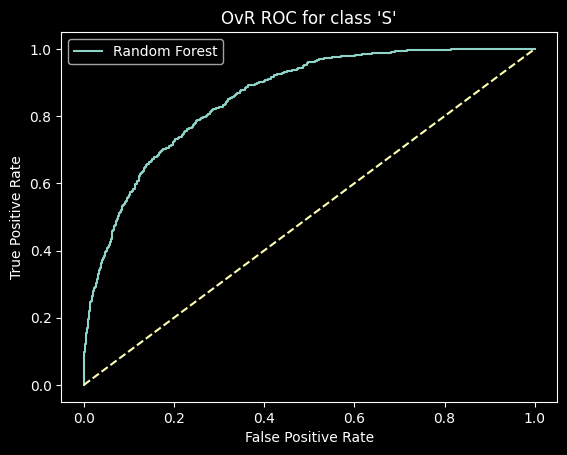

In [17]:
for cls in np.unique(y_test):
    plt.figure()
    for r in results:
        plt.plot(
            r["fpr"][cls],
            r["tpr"][cls],
            label=r["model"]
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"OvR ROC for class '{cls}'")
    plt.legend()
    plt.show()
